# 7. Comparing across time or place

This is the last notebook in the series, and it puts everything together. Across the previous six notebooks we built up a toolbox: finding candidate formulas ([3](03-finding-repeated-phrases.ipynb)), handling spelling variation ([4](04-old-spelling-same-phrase.ipynb)), finding document boundaries ([5](05-where-do-documents-begin-and-end.ipynb)), and consolidating and naming formulas ([6](06-naming-your-formulas.ipynb)). Here, we use that toolbox to answer a real historical question:

> **Did the *amount* of formulaic language in these resolutions change over time?**

We'll compare three five-year periods, roughly 80 and 160 years apart: 1606&ndash;1610, 1696&ndash;1700, and 1766&ndash;1770.

## Loading three periods

Each period is provided as several files (one per year or per volume), so we'll write a small helper to load and combine them. This is the same tokenizing approach as every previous notebook, just applied to more than one file at a time.

In [1]:
import csv
import gzip
import math
import re
from collections import Counter

TOKEN_PATTERN = re.compile(r"[A-Za-z\u00c0-\u00ff]+")


def tokenize(text):
    return TOKEN_PATTERN.findall(text.lower())


PERIODS = {
    '1606-1610': [3156, 3158, 3160, 3162, 3164],
    '1696-1700': list(range(3333, 3343)),
    '1766-1770': list(range(3821, 3826)),
}


def load_period(period_name):
    rows = []
    for file_number in PERIODS[period_name]:
        path = f'data/resolution_paragraphs/paragraphs-{file_number}.tsv.gz'
        with gzip.open(path, 'rt', encoding='utf-8') as f:
            rows.extend(csv.DictReader(f, delimiter='\t'))
    documents = [tokenize(row['text']) for row in rows]
    flat_stream = [token for doc in documents for token in doc]
    return documents, flat_stream


period_data = {}
for period in PERIODS:
    documents, flat_stream = load_period(period)
    period_data[period] = {'documents': documents, 'flat_stream': flat_stream}
    print(f'{period}: {len(documents):,} paragraphs, {len(flat_stream):,} tokens')

1606-1610: 46,499 paragraphs, 1,364,385 tokens


1696-1700: 81,219 paragraphs, 3,022,128 tokens


1766-1770: 15,305 paragraphs, 2,569,386 tokens


## Choosing a fair way to measure "how formulaic"

The three periods are quite different sizes (the middle one is more than twice the size of the others), so we can't just count how many formulaic phrases occur &mdash; a bigger corpus would always win. We need a measure that's comparable regardless of size.

We'll use **coverage**: the percentage of *all* the words in a period that fall inside an occurrence of one of its formulaic phrases. A period where formulas make up a large share of the text scores high; a period where most of the text is one-off, free-composed wording scores low. This is a fraction, so it can be compared directly across periods of any size.

## Finding and consolidating formulas, per period

For each period, we repeat exactly the steps from notebooks 3 and 6: discover candidate phrases, then consolidate overlapping fragments into clean canonical phrases. The only new thing is scaling the frequency threshold to each period's size, so that a phrase needs to be proportionally just as common to qualify, regardless of which period it's in.

In [2]:
from formula_detection.search import FormulaSearch
from formula_detection.phrase_cooccurrence import PhraseCooccurrenceIndex
from formula_detection.motif import merge_overlapping_phrases, merge_phrase_positions


def discover_and_consolidate(documents, flat_stream, top_n=40, window=5):
    min_term_freq = max(5, len(flat_stream) // 5000)  # scale the threshold to corpus size
    formula_search = FormulaSearch(documents, min_term_freq=min_term_freq, skip_size=2,
                                   min_cooc_freq=min_term_freq, max_min_term_frac=0.05, report=False)

    phrase_freq = Counter()
    for match in formula_search.extract_phrases('sub_phrases', min_phrase_length=3, max_phrase_length=6,
                                                min_neighbour_cooc=1):
        phrase_freq[match.candidate_phrase.phrase_string] += 1
    candidate_phrases = [phrase for phrase, _ in phrase_freq.most_common(top_n)]

    cooc_index = PhraseCooccurrenceIndex(candidate_phrases, windows=[window])
    cooc_index.index_stream(flat_stream)
    phrase_to_canonical = merge_overlapping_phrases(cooc_index.phrase_positions, window=window,
                                                     min_support=5, min_lift=3.0)
    return merge_phrase_positions(cooc_index.phrase_positions, phrase_to_canonical, dedup_distance=3)


for period, data in period_data.items():
    merged_positions = discover_and_consolidate(data['documents'], data['flat_stream'])
    data['merged_positions'] = merged_positions
    print(f'{period}: {len(merged_positions)} canonical formulas found')

1. Iterating over sentences to calculate term frequencies


    full collection size (tokens): 1,364,385
    full lexicon size (types): 50,845
    minimum term frequency: 272
    minimum frequency lexicon size: 622
2. Iterating over sentences to calculate the co-occurrence frequencies


docs: 46,499	num_words: 1,364,385	num_coocs: 1,960,953	num distinct coocs: 161,564
    co-occurrence index size: 161,564
Minimum co-occurrence frequency: 272


1606-1610: 12 canonical formulas found
1. Iterating over sentences to calculate term frequencies


    full collection size (tokens): 3,022,128
    full lexicon size (types): 70,139
    minimum term frequency: 604
    minimum frequency lexicon size: 589
2. Iterating over sentences to calculate the co-occurrence frequencies


docs: 81,219	num_words: 3,022,128	num_coocs: 5,001,431	num distinct coocs: 141,727
    co-occurrence index size: 141,727
Minimum co-occurrence frequency: 604


1696-1700: 8 canonical formulas found
1. Iterating over sentences to calculate term frequencies


    full collection size (tokens): 2,569,386
    full lexicon size (types): 53,340
    minimum term frequency: 513
    minimum frequency lexicon size: 535
2. Iterating over sentences to calculate the co-occurrence frequencies


docs: 15,305	num_words: 2,569,386	num_coocs: 4,600,080	num distinct coocs: 117,076
    co-occurrence index size: 117,076
Minimum co-occurrence frequency: 513


1766-1770: 11 canonical formulas found


## Measuring coverage

Now we mark every token that falls inside any formula occurrence, and compute what fraction of each period's tokens that comes to.

In [3]:
def measure_coverage(merged_positions, flat_stream):
    covered = bytearray(len(flat_stream))
    for phrase, positions in merged_positions.items():
        phrase_length = len(phrase.split())
        for position in positions:
            for i in range(position, min(position + phrase_length, len(flat_stream))):
                covered[i] = 1
    return sum(covered) / len(flat_stream)


for period, data in period_data.items():
    coverage = measure_coverage(data['merged_positions'], data['flat_stream'])
    data['coverage'] = coverage
    print(f'{period}: {coverage:.1%} of all tokens fall inside a formulaic phrase')

1606-1610: 0.9% of all tokens fall inside a formulaic phrase
1696-1700: 6.0% of all tokens fall inside a formulaic phrase
1766-1770: 6.5% of all tokens fall inside a formulaic phrase


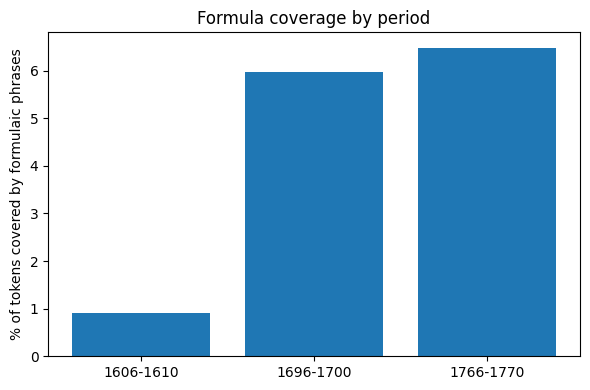

In [4]:
import matplotlib.pyplot as plt

periods_ordered = list(PERIODS.keys())
coverages = [period_data[period]['coverage'] * 100 for period in periods_ordered]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(periods_ordered, coverages, color='tab:blue')
ax.set_ylabel('% of tokens covered by formulaic phrases')
ax.set_title('Formula coverage by period')
plt.tight_layout()
plt.show()

## What this tells us, and what it doesn't

There's a clear, large jump in coverage between 1606&ndash;1610 and the two later periods, with comparatively little further change between 1696&ndash;1700 and 1766&ndash;1770. In other words: this particular measure suggests formulaic language use rose sharply at some point between the early 1600s and the end of that century, and had already levelled off by the time we get to the 1760s &mdash; not a smooth, continuous increase across the whole two centuries.

That's a more specific, more interesting claim than "it increased", and it's the kind of claim that's worth checking carefully before trusting:

* **We only have one data point before the rise.** A real test of *when* and *how* it changed would need at least one more period between 1610 and 1696, to see whether the change was gradual or sudden.
* **This measure tracks *how much* of the text is formulaic, not *what kind* of formulaic.** Notebook 6's organising tools applied to all three periods, with a shared set of category names, would let you ask a sharper question: which specific *kinds* of formula grew, and which stayed the same?
* **The choice of candidate-phrase parameters can matter.** We used the same settings for every period for fairness, but it's worth checking that the conclusion holds up if those settings change a little &mdash; a point also raised honestly in `Document-Pattern-Detection-Findings.md`, alongside other lessons learned from applying these tools to real, messy historical text rather than clean toy examples.

## Where to go from here

This series covered the core toolbox at a deliberately gentle pace, using one running example throughout. The toolkit has more to offer beyond what we've covered:

* `Document-Pattern-Detection.ipynb` and `Motif-Based-Boundary-Detection.ipynb` cover the more advanced, automatic versions of the boundary-finding and pattern-discovery ideas from notebooks 5 and 6 &mdash; useful once you've outgrown picking opener phrases by hand.
* `Phrase-Recurrence-Scale-Grouping.ipynb` looks more closely at how a formula's own recurrence interval can hint at what level of document structure it belongs to (a single decision, a whole resolution, a whole day's session).
* `Formulaic-Language-Over-Time.ipynb` repeats this notebook's comparison in more depth, with additional metrics and a wider discussion.
* `Document-Pattern-Detection-Findings.md` is an honest account of what worked, what didn't, and why, written while building these tools against real historical material &mdash; worth reading before you spend a long time tuning a parameter that turns out not to matter much.
* The full reference documentation describes every function and class in the toolkit in detail, for whenever you need more control than these tutorials provide.

Whatever question brought you to this toolkit, the right next step is usually the same one we followed throughout this series: start with the simplest version of an analysis that could plausibly answer your question, check the result against examples you can read and understand by eye, and only add complexity once you've established that the simple version isn't enough.